# Fine-Turning for Classification

The most common ways to fine-tune language models are instruction fine-tuning and classification fine-tuning. Instruction fine-tuning involves training a language model on a set of tasks using specific instructions to improve its ability to understand and execute tasks described in natural language prompts.

The key point is that a classification fine-tuned model is restricted to predicting classes it has encountered during its training. For instance, it can determine whether
something is “spam” or “not spam,” as illustrated in figure 6.3, but it can’t say anything else about the input text.

#### Choosing the right approach

Instruction fine-tuning improves a model’s ability to understand and generate responses based on specific user instructions. Instruction fine-tuning is best suited for models that need to handle a variety of tasks based on complex user instructions, improving flexibility and interaction quality. Classification fine-tuning is ideal for projects requiring precise categorization of data into predefined classes, such as sentiment analysis or spam detection.

While instruction fine-tuning is more versatile, it demands larger datasets and greater computational resources to develop models proficient in various tasks. In contrast,
classification fine-tuning requires less data and compute power, but its use is confined to the specific classes on which the model has been trained.

### Preparing the dataset

We will modify and classification fine-tune the GPT model we previously implemented and pretrained.

 To provide an intuitive and useful example of classification fine-tuning, we will work with a text message dataset that consists of spam and non-spam messages.

The first step is to download the dataset:

In [3]:
import pathlib
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "data/sms_spam_collection.zip"
extracted_path = "data/sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
      "and extraction.")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as data\sms_spam_collection\SMSSpamCollection.tsv


In [4]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


Executing the previous code, we find that the data contains “ham” (i.e., not spam) far more frequently than “spam”. For simplicity, and because we prefer a small dataset (which will facilitate faster fine tuning of the LLM), we choose to undersample the dataset to include 747 instances from each class.

We can use the code in the following listing to undersample and create a balanced dataset.

In [32]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
        )
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    ])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())
balanced_df

Label
ham     747
spam    747
Name: count, dtype: int64


,Label,Text
4307,ham,Awww dat is sweet! We can think of something t...
4138,ham,Just got to &lt;#&gt;
4831,ham,"The word ""Checkmate"" in chess comes from the P..."
4461,ham,This is wishing you a great day. Moji told me ...
5440,ham,Thank you. do you generally date the brothas?
...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...


Next, we convert the “string” class labels "ham" and "spam" into integer class labels 0 and 1, respectively:

In [33]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
balanced_df.head()

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?


Next, we create a random_split function to split the dataset into three parts: 70% for training, 10% for validation, and 20% for testing. (These ratios are common in machine learning to train, adjust, and evaluate models.)

In [34]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(
    frac=1, random_state=123
        ).reset_index(drop=True)                # shuffle the entire dataset
    train_end = int(len(df) * train_frac)       # calculate the split indices
    validation_end = train_end + int(len(df) * validation_frac)

    # split the dataset into train, validation, and test sets
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1)                      # test size is implied to be 0.2 as the remainer

Let’s save the dataset as CSV (comma-separated value) files so we can reuse it later:

In [35]:
import pathlib

if(pathlib.Path("data/spam").exists() == False):
    pathlib.Path("data/spam").mkdir()

train_df.to_csv("data/spam/train.csv", index=None)
validation_df.to_csv("data/spam/validation.csv", index=None)
test_df.to_csv("data/spam/test.csv", index=None)

### Creating data loaders

We will develop PyTorch data loaders conceptually similar to those we implemented while working with text data. Previously, we utilized a sliding window technique to generate uniformly sized text chunks, which we then grouped into batches for more efficient model training. Each chunk functioned as an individual training instance.
However, we are now working with a spam dataset that contains text messages of varying lengths. To batch these messages as we did with the text chunks, we have two primary options:

- Truncate all messages to the length of the shortest message in the dataset or batch.
- Pad all messages to the length of the longest message in the dataset or batch.
-
The first option is computationally cheaper, but it may result in significant information loss if shorter messages are much smaller than the average or longest messages,
potentially reducing model performance. So, we opt for the second option, which preserves the entire content of all messages.

To implement batching, where all messages are padded to the length of the longest message in the dataset, we add padding tokens to all shorter messages. For this purpose, we use "<|endoftext|>" as a padding token.

However, instead of appending the string "<|endoftext|>" to each of the text messages directly, we can add the token ID corresponding to "<|endoftext|>" to the
encoded text messages. 50256 is the token ID of the padding token "<|endoftext|>". We can double-check whether the token ID is correct by encoding the "<|endoftext|>" using the GPT-2 tokenizer from the tiktoken package that we used previously:

In [36]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


Indeed, executing the preceding code returns [50256].

We first need to implement a PyTorch Dataset, which specifies how the data is loaded and processed before we can instantiate the data loaders. For this purpose, we define the SpamDataset class.  This SpamDataset class handles several key tasks: it encodes the text messages into token sequences, identifies the longest sequence in the training dataset, and ensures that all other sequences are padded with a padding token to match the length of the longest sequence.

In [20]:
from src.Utilities.SpamDataset import SpamDataset

 Now we create the batches in the training data loader:

In [37]:
train_dataset = SpamDataset(
    csv_file="data/spam/train.csv",
    max_length=None,
    tokenizer=tokenizer
)

The longest sequence length is stored in the dataset’s max_length attribute. If you are curious to see the number of tokens in the longest sequence, you can use the following code:

In [38]:
print(train_dataset.max_length)

120


The code outputs 120, showing that the longest sequence contains no more than 120 tokens, a common length for text messages. The model can handle sequences of up to 1,024 tokens, given its context length limit. If your dataset includes longer texts, you can pass max_length=1024 when creating the training dataset in the preceding code to ensure that the data does not exceed the model’s supported input (context) length.

Next, we pad the validation and test sets to match the length of the longest training sequence. Importantly, any validation and test set samples exceeding the length of
the longest training example are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier. This truncation is optional; you can set
max_length=None for both validation and test sets, provided there are no sequences exceeding 1,024 tokens in these sets:

In [39]:
val_dataset = SpamDataset(
    csv_file="data/spam/validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="data/spam/test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

Note: Increasing the context length by padding to the maximum number of tokens the model supports will affect predictive performance.

Using the datasets as inputs, we can instantiate the data loaders similarly to when we were working with text data. However, in this case, the targets represent class labels
rather than the next tokens in the text. For instance, if we choose a batch size of 8, each batch will consist of eight training examples of length 120.

The code in the following listing creates the training, validation, and test set data loaders that load the text messages and labels in batches of size 8.

In [40]:
import torch
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

To ensure that the data loaders are working and are, indeed, returning batches of the expected size, we iterate over the training loader and then print the tensor dimensions of the last batch:

In [41]:
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


As we can see, the input batches consist of eight training examples with 120 tokens each, as expected. The label tensor stores the class labels corresponding to the eight training examples.

Lastly, to get an idea of the dataset size, let’s print the total number of batches in each dataset:

In [42]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


Now that we’ve prepared the data, we need to prepare the model for fine-tuning.

### Initializing a model with pretrained weights

We must prepare the model for classification fine-tuning to identify spam messages.
We start by initializing our pretrained model.

To begin the model preparation process, we employ the same configurations we used to pretrain unlabeled data:

In [46]:
SELECTED_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "dropout": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"embedding_dim": 768, "num_layers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"embedding_dim": 1024, "num_layers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"embedding_dim": 1280, "num_layers": 36, "num_heads": 20},
    "gpt2-xl (1558M)": {"embedding_dim": 1600, "num_layers": 48, "num_heads": 25},
}
BASE_CONFIG.update(model_configs[SELECTED_MODEL])

Next, we import the download_and_load_gpt2 function from the gpt_download.py file and reuse the GPTModel class and load_weights_into_gpt function from pretraining to load the downloaded weights into the GPT model.

In [47]:
from src.Utilities.GPT2WeightDownloader import download_and_load_gpt2
from src.Architecture.GPTModel import GPTModel
from src.Utilities.GPTWeightLoader import load_weights_into_gpt

model_size = SELECTED_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): 

After loading the model weights into the GPTModel, we reuse the text generation utility function to ensure that the model generates coherent text:

In [48]:
from src.Utilities.GenerationUtilities import generate_text_simple, text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


We see that the  model generates coherent text, which is indicates that the model weights have been loaded correctly!

Before we start fine-tuning the model as a spam classifier, let’s see whether the model already classifies spam messages by prompting it with instructions:

In [49]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


Based on the output, it’s apparent that the model is struggling to follow instructions. This result is expected, as it has only undergone pretraining and lacks instruction
fine-tuning. So, let’s prepare the model for classification fine-tuning.

### Adding a classification head

We must modify the pretrained LLM to prepare it for classification fine-tuning. To do so, we replace the original output layer, which maps the hidden representation to a vocabulary of 50,257, with a smaller output layer that maps to two classes: 0 (“not spam”) and 1 (“spam”)

We use the same model as before, except we replace the output layer.

#### Note: Output layer nodes

We could technically use a single output node since we are dealing with a binary classification task. However, it would require modifying the loss function, as I discuss in
“Losses Learned—Optimizing Negative Log-Likelihood and Cross-Entropy in PyTorch” (https://mng.bz/NRZ2). Therefore, we choose a more general approach, where the number of output nodes matches the number of classes. For example, for a three class problem, such as classifying news articles as “Technology,” “Sports,” or “Politics,” we would use three output nodes, and so forth.

Before we attempt the modification shown in figure 6.9, let’s print the model architecture via print(model):

In [50]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): 

As previously discussed, the GPTModel consists of embedding layers followed by 12 identical transformer blocks (only the last block is shown for brevity), followed by a final LayerNorm and the output layer, out_head.

Next, we replace the out_head with a new output layer that we will fine-tune.

#### Fine-tuning selected layers vs. all layers

Since we start with a pretrained model, it’s not necessary to fine-tune all model layers. In neural network-based language models, the lower layers generally capture basic language structures and semantics applicable across a wide range of tasks and datasets. **_So, fine-tuning only the last layers (i.e., layers near the output), which are more specific to nuanced linguistic patterns and task-specific features, is often sufficient to adapt the model to new tasks. A nice side effect is that it is computationally more efficient to fine tune only a small number of layers.**_

To get the model ready for classification fine-tuning, we first freeze the model, meaning that we make all layers nontrainable:

In [51]:
for param in model.parameters():
    param.requires_grad = False

Then, we replace the output layer (model.out_head), which originally maps the layer inputs to 50,257 dimensions, the size of the vocabulary

In [53]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["embedding_dim"],
    out_features=num_classes
)

To keep the code more general, we use BASE_CONFIG["emb_dim"], which is equal to 768 in the "gpt2-small (124M)" model. Thus, we can also use the same code to work
with the larger GPT-2 model variants.

This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it’s the only layer in the model that will be
updated during training. Technically, training the output layer we just added is sufficient. **_However, as I found in experiments, fine-tuning additional layers can noticeably improve the predictive performance of the model.**_ (For more details, refer to appendix B.) We also configure the last transformer block and the final LayerNorm
module, which connects this block to the output layer, to be trainable.

To make the final LayerNorm and last transformer block trainable, we set their respective requires_grad to True:

In [55]:
for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

Even though we added a new output layer and marked certain layers as trainable or nontrainable, we can still use this model similarly to how we have previously. For instance, we can feed it an example text identical to our previously used example text:

In [56]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # (batch_size, number of tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


The print output shows that the preceding code encodes the inputs into a tensor consisting of four input tokens.
Then, we can pass the encoded token IDs to the model as usual.

In [57]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5840,  0.9893],
         [-3.7231,  7.4521],
         [-2.2664,  6.6035],
         [-3.5974,  3.9887]]])
Outputs dimensions: torch.Size([1, 4, 2])


A similar input would have previously produced an output tensor of [1, 4, 50257], where 50257 represents the vocabulary size. The number of output rows corresponds to the number of input tokens (in this case, four). However, each output’s embedding dimension (the number of columns) is now 2 instead of 50,257 since we replaced the output layer of the model.

Remember that we are interested in fine-tuning this model to return a class label indicating whether a model input is “spam” or “not spam.” We don’t need to fine tune all four output rows; instead, we can focus on a single output token. In particular, we will focus on the last row corresponding to the last output token.

To extract the last output token from the output tensor, we use the following code:

In [58]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5974,  3.9887]])


We still need to convert the values into a class-label prediction. But first, let’s understand why we are particularly interested in the last output token only. We have already explored the attention mechanism, which establishes a relationship between each input token and every other input token, and the concept of a causal attention mask, commonly used in GPT-like models (see chapter 3). This mask restricts a token’s focus to its current position and the those before it, ensuring that each token
can only be influenced by itself and the preceding tokens.

Given the causal attention mask setup, the last token in a sequence accumulates the most information since it is the only token with access to data from all the previous tokens. Therefore, in our spam classification task, we focus on this last token during the fine-tuning process.

We are now ready to transform the last token into class label predictions and calculate the model’s initial prediction accuracy. Subsequently, we will fine-tune the model for the spam classification task.

### Calculating the classification loss and accuracy

Only one small task remains before we fine-tune the model: we must implement the model evaluation functions used during fine-tuning.

Before implementing the evaluation utilities, let’s briefly discuss how we convert the model outputs into class label predictions. We previously computed the token ID
of the next token generated by the LLM by converting the 50,257 outputs into probabilities via the softmax function and then returning the position of the highest probability via the argmax function. We take the same approach here to calculate whether the model outputs a “spam” or “not spam” prediction for a given input.

The only difference is that we work with 2-dimensional instead of 50,257 dimensional outputs.

Let’s consider the last token output using a concrete example:

In [59]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5974,  3.9887]])


We can obtain the class label:

In [60]:
probs = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probs)
print("Class label:", label.item())

Class label: 1


In this case, the code returns 1, meaning the model predicts that the input text is “spam.” Using the softmax function here is optional because the largest outputs directly correspond to the highest probability scores. Hence, we can simplify the code without using softmax:

In [61]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


This concept can be used to compute the classification accuracy, which measures the percentage of correct predictions across a dataset.

To determine the classification accuracy, we apply the argmax-based prediction code to all examples in the dataset and calculate the proportion of correct predictions by defining a calc_accuracy_loader function.

In [62]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]       # logits of last output token

            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                    (predicted_labels == target_batch).sum().item()
            )
        else:
            break
    return correct_predictions / num_examples

Let’s use the function to determine the classification accuracies across various datasets estimated from 10 batches for efficiency:

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


As we can see, the prediction accuracies are near a random prediction, which would be 50% in this case. To improve the prediction accuracies, we need to fine-tune the model.

However, before we begin fine-tuning the model, we must define the loss function we will optimize during training. Our objective is to maximize the spam classification
accuracy of the model, which means that the preceding code should output the correct class labels: 0 for non-spam and 1 for spam.

Because classification accuracy is not a differentiable function, we use cross entropy loss as a proxy to maximize accuracy. Accordingly, the calc_loss_batch function remains the same, with one adjustment: we focus on optimizing only the last token, model(input_batch)[:, -1, :], rather than all tokens, model(input_batch):

In [64]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]           # logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

We use the calc_loss_batch function to compute the loss for a single batch obtained from the previously defined data loaders. To calculate the loss for all batches in a data
loader, we define the calc_loss_loader function as before.

In [65]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))        # Ensures the number of batches doesn't exceed batches in data loader

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

Similar to calculating the training accuracy, we now compute the initial loss for each data set:

In [66]:
with torch.no_grad():           # disable gradient tracking for efficiency since we are not training
    train_loss = calc_loss_loader(
train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.455
Validation loss: 2.585
Test loss: 2.324


Next, we will implement a training function to fine-tune the model, which means adjusting the model to minimize the training set loss. Minimizing the training set loss will help increase the classification accuracy, which is our overall goal.

### Fine-tuning the model on supervised data

We must define and use the training function to fine-tune the pretrained LLM and improve its spam classification accuracy. The training loop, is the same overall training loop we used for pretraining; the only difference is that we calculate the classification accuracy instead of generating a sample text to evaluate the model.

The training function closely mirrors the train_model_simple function used for pretraining the model. The only two distinctions are that we now track the number of training examples seen (examples_seen) instead of the number of tokens, and we calculate the accuracy after each epoch instead of printing a sample text.

In [67]:
from src.Utilities.TrainingUtilities import evaluate_model

def train_classifier_simple(model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []     #Initialize lists to track losses and examples seen
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()                                   # Sets model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                       # Reset gradients from previous batch
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                             # Calculates loss gradients
            optimizer.step()                            # updates model weights using loss gradients
            examples_seen += input_batch.shape[0]       # Tracks examples instead of tokens
            global_step += 1

            # optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

The evaluate_model function is identical to the one we used for pretraining.

In [68]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

Next, we initialize the optimizer, set the number of training epochs, and initiate the training using the train_classifier_simple function. The training takes about 6 minutes on an M3 MacBook Air laptop computer and less than half a minute on a V100 or A100 GPU:

In [69]:
import time
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.155, Val loss 2.394
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.560, Val loss 0.488
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.396
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.334, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.344, Val loss 0.312
Training accuracy: 85.00% | Validation accuracy: 85.00%
Ep 4 (Step 000400): Train loss 0.201, Val loss 0.269
Ep 4 (Step 000450): Train loss 0.179, Val loss 0.156
Ep 4 (Step 000500): Train loss 0.230, Val loss 0.154
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.209, Val loss 0.156
Ep 5 (Step 000600): Train loss 0.096, Val loss 0.080
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 5.16 mi

We then use Matplotlib to plot the loss function for the training and validation set.

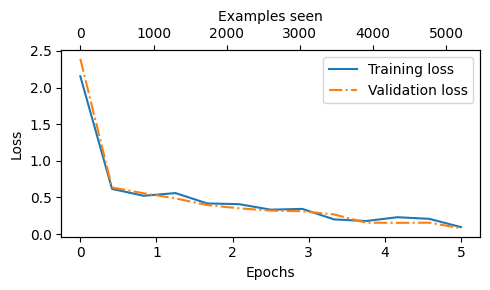

In [70]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values,
    label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

As we can see based on the sharp downward slope, the model is learning well from the training data, and there is little to no indication of overfitting; that is, there is no noticeable gap between the training and validation set losses.

#### Choosing the number of epochs

Earlier, when we initiated the training, we set the number of epochs to five. The number of epochs depends on the dataset and the task’s difficulty, and there is no universal solution or recommendation, although an epoch number of five is usually a good starting point. If the model overfits after the first few epochs as a loss plot , you may need to reduce the number of epochs. Conversely, if the trendline suggests that the validation loss could improve with further training, you should increase the number of epochs. In this concrete case, five epochs is a reasonable number as there are no signs of early overfitting, and the validation loss is close to 0.

Using the same plot_values function, let’s now plot the classification accuracies:

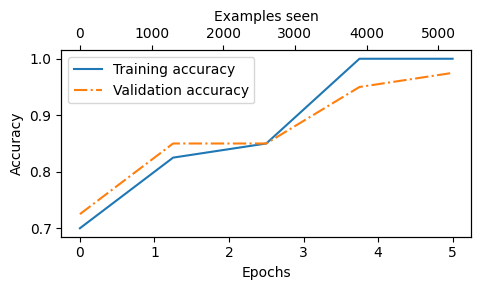

In [71]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

The model achieves a relatively high training and validation accuracy after epochs 4 and 5. Importantly, we previously set eval_iter=5 when using the train_classifier_simple function, which means our estimations of training and validation performance are based on only five batches for efficiency during training.

Now we must calculate the performance metrics for the training, validation, and test sets across the entire dataset by running the following code, this time without defining the eval_iter value:

In [72]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 96.63%
Validation accuracy: 97.32%
Test accuracy: 95.67%


The training and test set performances are almost identical. The slight discrepancy between the training and test set accuracies suggests minimal overfitting of the training data. Typically, the validation set accuracy is somewhat higher than the test set accuracy because the model development often involves tuning hyperparameters to
perform well on the validation set, which might not generalize as effectively to the test set. This situation is common, but the gap could potentially be minimized by adjusting the model’s settings, such as increasing the dropout rate (drop_rate) or the weight_decay parameter in the optimizer configuration.

### Using the LLM as a spam classifier

Having fine-tuned and evaluated the model, we are now ready to classify spam messages. Let’s use our fine-tuned GPT-based spam classification model.

The following classify_review function follows data preprocessing steps similar to those we used in the SpamDataset implemented earlier. Then, after processing text into token IDs, the function uses the model to predict an integer class label, similar to what we implemented in section 6.6, and then returns the corresponding class name.

In [73]:
def classify_review(text, model, tokenizer, device, max_length=None,pad_token_id=50256):
    model.eval()
    input_ids = tokenizer.encode(text)                                      # Convert text to token IDs
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(max_length, supported_context_length)]       # Truncate input if necessary

    input_ids += [pad_token_id] * (max_length - len(input_ids))             # pads sequence to max_length
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)      # adds batch dimension
    with torch.no_grad():                                                   # model inference without gradient tracking
        logits = model(input_tensor)[:, -1, :]

    predicted_label = torch.argmax(logits, dim=-1).item()
    return "spam" if predicted_label == 1 else "not spam"

Let’s try this classify_review function on an example text:

In [87]:
text_1 = (
    "URGENT!! You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award. FINAL"
    " DATE: 10/15/2023. Please reply to this email with your"
    " full name, address, and phone number. Thank you."
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [88]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


The model again makes a correct prediction and returns a “not spam” label.

 Finally, let’s save the model in case we want to reuse the model later without having to train it again. We can use the torch.save method:

In [ ]:
torch.save(model.state_dict(), "review_classifier.pth")

Once saved, the model can be loaded:

In [ ]:
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)


### Summary
- There are different strategies for fine-tuning LLMs, including classification fine-tuning and instruction fine-tuning.
- Classification fine-tuning involves replacing the output layer of an LLM via a small classification layer.
- In the case of classifying text messages as “spam” or “not spam,” the new classification layer consists of only two output nodes. Previously, we used the number
of output nodes equal to the number of unique tokens in the vocabulary (i.e., 50,256).
- Instead of predicting the next token in the text as in pretraining, classification fine-tuning trains the model to output a correct class label—for example, “spam” or “not spam.”
- The model input for fine-tuning is text converted into token IDs, similar to pretraining.
- Before fine-tuning an LLM, we load the pretrained model as a base model.
- Evaluating a classification model involves calculating the classification accuracy (the fraction or percentage of correct predictions).
- Fine-tuning a classification model uses the same cross entropy loss function as when pretraining the LLM.